PART 1



In [ ]:
import yfinance as yf
import datetime as dt

# Start and end dates (last 3 years)
s = dt.datetime(2022, 12, 9)
e = dt.datetime(2025, 12, 9)

# Individual tickers
t1 = ['KLAC']        #  klac 
t2 = ['GM']       # gm
t3 = ['orly']        #orly

# Download data
klac = yf.download(t1, start=s, end=e)
gm = yf.download(t2, start=s, end=e)
orly = yf.download(t3, start=s, end=e)

# Save CSV files
klac.to_csv('KLAC.csv')
gm.to_csv('GM.csv')
orly.to_csv('ORLY.csv')

print("Downloaded all 3 companies' data successfully!")


C:\Users\840 G5\AppData\Local\Temp\ipykernel_20008\1965964343.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  klac = yf.download(t1, start=s, end=e)
[*********************100%***********************]  1 of 1 completed
C:\Users\840 G5\AppData\Local\Temp\ipykernel_20008\1965964343.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gm = yf.download(t2, start=s, end=e)
[*********************100%***********************]  1 of 1 completed
C:\Users\840 G5\AppData\Local\Temp\ipykernel_20008\1965964343.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  orly = yf.download(t3, start=s, end=e)
[*********************100%***********************]  1 of 1 completed

Downloaded all 3 companies' data successfully!


In [ ]:
#printing data of klacstock prices
#gives us full klac (Open, High, Low, Close) data
print(klac.head(20))

Price            Close        High         Low        Open   Volume
Ticker            KLAC        KLAC        KLAC        KLAC     KLAC
Date                                                               
2022-12-09  382.003448  388.926726  376.361906  380.546940  1380300
2022-12-12  389.286011  389.383117  372.584696  374.225699  1555800
2022-12-13  397.170532  407.404942  391.859129  403.608306  2221900
2022-12-14  394.432281  402.035274  390.082194  396.529658  1557000
2022-12-15  373.594543  388.052836  372.138035  386.508911  2091600
2022-12-16  374.361633  376.517268  369.225004  370.963113  2360900
2022-12-19  372.536041  374.633417  368.418987  373.808056  1122800
2022-12-20  374.720917  378.439857  367.486910  369.749371   903400
2022-12-21  385.275726  386.586590  376.342460  377.536808  1125000
2022-12-22  363.010559  375.565658  356.417421  374.895662  2075700
2022-12-23  366.447937  367.040236  357.058297  361.447233   892000
2022-12-27  360.340302  365.350696  358.165228  

In [ ]:
#printing data of stock prices
#gives us full KLAC (Open, High, Low, Close) data
print(klac.head(20))

Price            Close        High         Low        Open   Volume
Ticker            KLAC        KLAC        KLAC        KLAC     KLAC
Date                                                               
2022-12-09  382.003448  388.926726  376.361906  380.546940  1380300
2022-12-12  389.286011  389.383117  372.584696  374.225699  1555800
2022-12-13  397.170532  407.404942  391.859129  403.608306  2221900
2022-12-14  394.432281  402.035274  390.082194  396.529658  1557000
2022-12-15  373.594543  388.052836  372.138035  386.508911  2091600
2022-12-16  374.361633  376.517268  369.225004  370.963113  2360900
2022-12-19  372.536041  374.633417  368.418987  373.808056  1122800
2022-12-20  374.720917  378.439857  367.486910  369.749371   903400
2022-12-21  385.275726  386.586590  376.342460  377.536808  1125000
2022-12-22  363.010559  375.565658  356.417421  374.895662  2075700
2022-12-23  366.447937  367.040236  357.058297  361.447233   892000
2022-12-27  360.340302  365.350696  358.165228  

PART 2 ARIMA Model

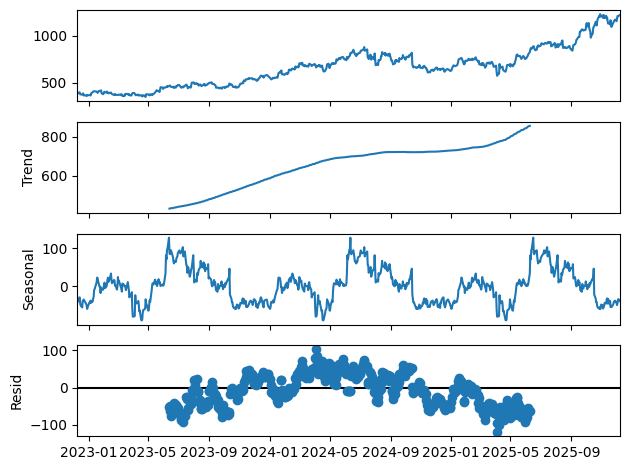

In [5]:
#ETS Decomposition is used to separate different components of a time series. The term ETS stands for Error, Trend, and Seasonality

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(klac['Close'], model='additive', period=252)
result.plot()
plt.show()

In [6]:
"""Now to perform adf test for checking stationarity of the data"""
from statsmodels.tsa.stattools import adfuller
result = adfuller(klac['Close'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")


ADF Statistic: 0.20276570129560406
p-value: 0.9724162877764497
The series is non-stationary


In [7]:
# We can use auto_arima to find the best parameters for ARIMA model

import pmdarima as pm

#Ignore harmless warnings

import warnings
warnings.filterwarnings("ignore")

prices_data = klac['Close'].dropna()

stepwise_model = pm.auto_arima(prices_data, start_p=0, start_q=0,
                                 max_p=5, max_q=5, m=1,
                                 start_P=0, seasonal=False,
                                 d=None, D=0, trace=True,
                                 error_action='ignore',  
                                 suppress_warnings=True, 
                                 stepwise=True)

stepwise_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6479.437, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6473.920, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6474.374, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6480.309, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=6475.238, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6475.266, Time=0.56 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=6477.180, Time=0.71 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=6475.402, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 2.059 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  751
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -3233.960
Date:                Sat, 13 Dec 2025   AIC                           6473.920
Time:                        01:20:39   BIC                           6487.780
Sample:                             0   HQIC                          6479.261
                                - 751                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2264      0.677      1.811      0.070      -0.101       2.554
ar.L1         -0.0998      0.026     -3.769      0.000      -0.152      -0.048
sigma2       326.0869      8.682     37.558      0.000     309.070     343.104
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              1262.93
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                            -0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
"""Now we will fit arima model on stock data of HPQ with the parameters obtained from auto_arima"""

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train-test split (last 12 days for testing)
train = prices_data.iloc[:-12]
test = prices_data.iloc[-12:]

# Fit SARIMAX (equivalent to ARIMA)
model = SARIMAX(train,
                order=(0, 1, 0),           # ARIMA(0,1,0)
                seasonal_order=(0, 0, 0, 0))

result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                   KLAC   No. Observations:                  739
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3180.566
Date:                Sat, 13 Dec 2025   AIC                           6363.132
Time:                        01:20:46   BIC                           6367.736
Sample:                             0   HQIC                          6364.908
                                - 739                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       324.2617      8.187     39.605      0.000     308.215     340.309
Ljung-Box (L1) (Q):                   6.44   Jarque-Bera (JB):              1426.13
Prob(Q):                              0.01   Pr

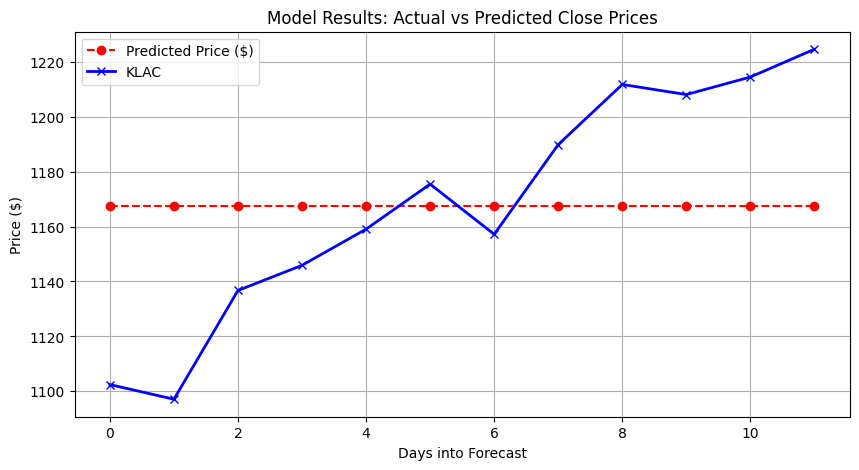

In [9]:
"""Prediction of Arima Model against test data"""

# Forecast on the test set
start = len(train)
end = len(train) + len(test) - 1
predictions = result.predict(start=start, end=end, dynamic=False, type='levels')

test_plot = test.reset_index(drop=True)
pred_plot = predictions.reset_index(drop=True)

# Compare Test vs Prediction
import matplotlib.pyplot as plt

# 1. Create the figure and the axes (the empty "frame")
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Plot the PREDICTED data on 'ax'
pred_plot.plot(ax=ax, label='Predicted Price ($)', color='red', marker='o', linestyle='--')

# 3. Plot the ACTUAL data on the SAME 'ax'
test_plot.plot(ax=ax, label='Actual Price ($)', color='blue', marker='x', linewidth=2)

# 4. Add labels and show
plt.xlabel("Days into Forecast")
plt.ylabel("Price ($)")
plt.title("Model Results: Actual vs Predicted Close Prices")
plt.legend()  # This makes the legend appear
plt.grid(True)
plt.show()





Forecasted Prices for the next 10 days:
2025-12-09    1224.589966
2025-12-10    1224.589966
2025-12-11    1224.589966
2025-12-12    1224.589966
2025-12-15    1224.589966
2025-12-16    1224.589966
2025-12-17    1224.589966
2025-12-18    1224.589966
2025-12-19    1224.589966
2025-12-22    1224.589966
Freq: B, Name: predicted_mean, dtype: float64


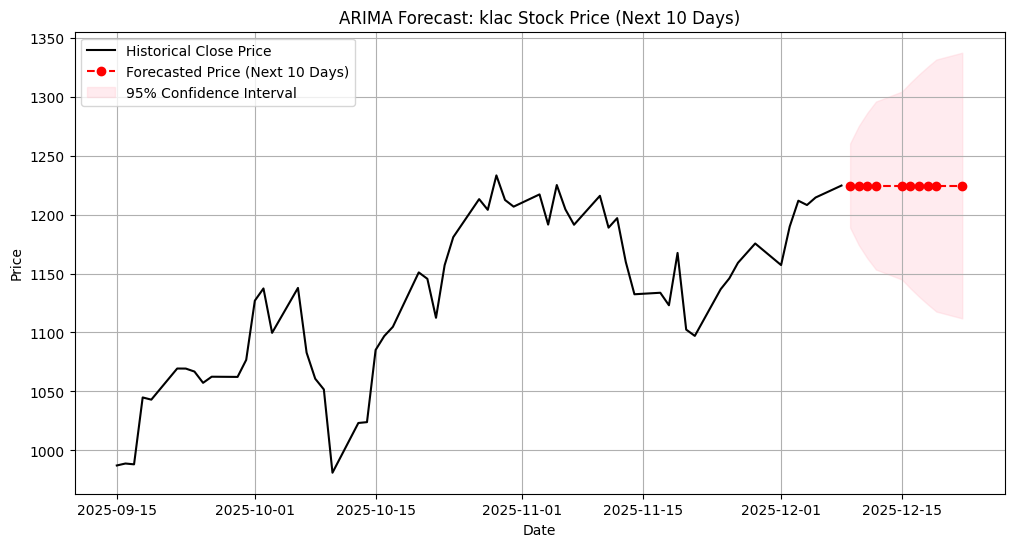

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. REFIT MODEL ON ALL DATA

full_data = klac['Close'].dropna()

model_final = SARIMAX(full_data, 
                      order=(0, 1, 0),          
                      seasonal_order=(0, 0, 0, 0))
result_final = model_final.fit()

# 2. GENERATE FORECAST (Next 10 Days)

forecast_steps = 10
forecast_obj = result_final.get_forecast(steps=forecast_steps)
forecast_vals = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)  # 95% Confidence Interval

# Create future dates (Business days)
last_date = full_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

# Assign dates to the forecast data
forecast_vals.index = future_dates
conf_int.index = future_dates



print("\nForecasted Prices for the next 10 days:")
print(forecast_vals)

# 3. VISUALIZE THE FORECAST
plt.figure(figsize=(12, 6))

# Plot only the last 60 days of history so the graph isn't too squished
plt.plot(full_data.index[-60:], full_data[-60:], label='Historical Close Price', color='black')

# Plot the Forecast
plt.plot(future_dates, forecast_vals, label='Forecasted Price (Next 10 Days)', color='red', marker='o', linestyle='--')

# Plot the Confidence Interval (The pink shaded area)
plt.fill_between(future_dates, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f"ARIMA Forecast: klac Stock Price (Next 10 Days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

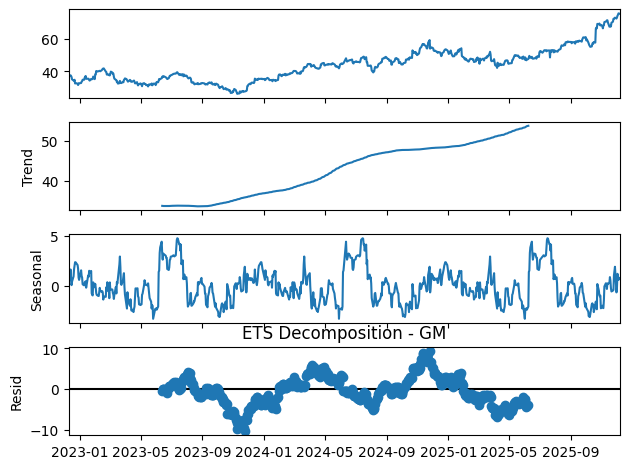

In [ ]:
# ETS Decomposition for gm
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Decomposition
result = seasonal_decompose(gm['Close'], model='additive', period=252)
result.plot()
plt.title('ETS Decomposition - GM')
plt.show()



In [13]:
# ADF Test
print('Results for gm:')
result = adfuller(gm['Close'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")

Results for gm:
ADF Statistic: 0.4786628626868995
p-value: 0.9842099377535516
The series is non-stationary


In [14]:
# Use auto_arima to find best parameters for gm
import warnings
warnings.filterwarnings("ignore")

prices_data = gm['Close'].dropna()

stepwise_model = pm.auto_arima(prices_data, start_p=0, start_q=0,
                                 max_p=5, max_q=5, m=1,
                                 start_P=0, seasonal=False,
                                 d=None, D=0, trace=True,
                                 error_action='ignore',  
                                 suppress_warnings=True, 
                                 stepwise=True)

print("\nBest Model Summary for gm:")
stepwise_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2101.542, Time=0.25 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2100.984, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2101.274, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2101.611, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2100.138, Time=0.20 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2101.823, Time=0.34 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2101.952, Time=0.77 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2101.603, Time=0.44 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2103.719, Time=1.33 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=2100.189, Time=0.07 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 3.799 seconds

Best Model Summary for gm:


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  751
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -1046.069
Date:                Sat, 13 Dec 2025   AIC                           2100.138
Time:                        01:23:00   BIC                           2118.619
Sample:                             0   HQIC                          2107.259
                                - 751                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0512      0.037      1.394      0.163      -0.021       0.123
ar.L1         -0.0547      0.032     -1.738      0.082      -0.116       0.007
ar.L2          0.0615      0.032      1.896      0.058      -0.002       0.125
sigma2         0.9528      0.021     46.387      0.000       0.913       0.993
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3839.72
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               2.76   Skew:                             0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

                               SARIMAX Results                                
Dep. Variable:                     GM   No. Observations:                  739
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1032.397
Date:                Sat, 13 Dec 2025   AIC                           2066.793
Time:                        01:23:52   BIC                           2071.397
Sample:                             0   HQIC                          2068.568
                                - 739                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.9607      0.019     49.956      0.000       0.923       0.998
Ljung-Box (L1) (Q):                   2.81   Jarque-Bera (JB):              4088.95
Prob(Q):                              0.09   Pr

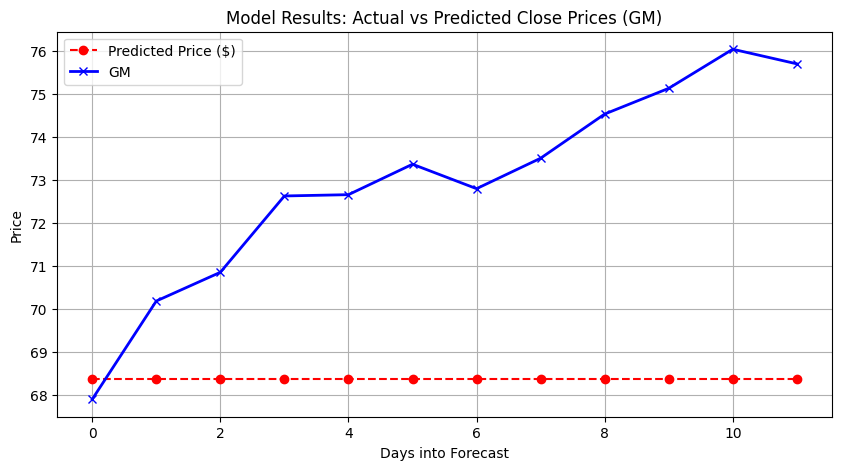

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Train-test split
train = prices_data.iloc[:-12]
test = prices_data.iloc[-12:]

# 2. Fit SARIMAX
# IMPORTANT: Update order=(p,d,q) below based on the 'Best Model' found in Step 3!
model = SARIMAX(train,
                order=(0, 1, 0),  # <--- UPDATE THIS based on auto_arima result
                seasonal_order=(0, 0, 0, 0))

result = model.fit()
print(result.summary())

# 3. Forecast on the test set
start = len(train)
end = len(train) + len(test) - 1
predictions = result.predict(start=start, end=end, dynamic=False, type='levels')

# 4. Plotting
test_plot = test.reset_index(drop=True)
pred_plot = predictions.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
pred_plot.plot(ax=ax, label='Predicted Price ($)', color='red', marker='o', linestyle='--')
test_plot.plot(ax=ax, label='Actual Price ($)', color='blue', marker='x', linewidth=2)
plt.xlabel("Days into Forecast")
plt.ylabel("Price")
plt.title("Model Results: Actual vs Predicted Close Prices (GM)")
plt.legend()
plt.grid(True)
plt.show()




Forecasted Prices for the next 10 days (GM):
2025-12-09    75.709999
2025-12-10    75.709999
2025-12-11    75.709999
2025-12-12    75.709999
2025-12-15    75.709999
2025-12-16    75.709999
2025-12-17    75.709999
2025-12-18    75.709999
2025-12-19    75.709999
2025-12-22    75.709999
Freq: B, Name: predicted_mean, dtype: float64


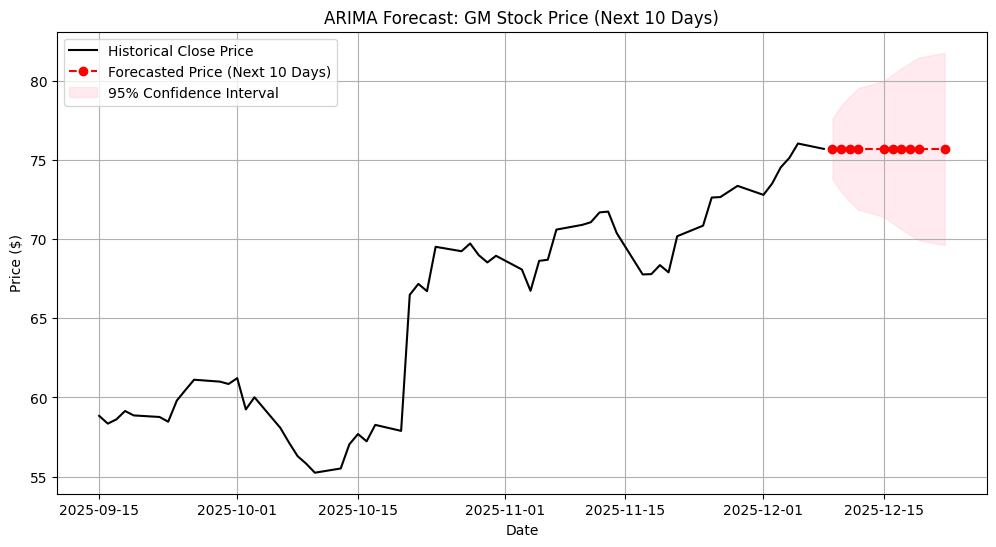

In [19]:
# Generate Forecast for Next 10 Days (GM)
full_data = gm['Close'].dropna()

# Refit model on ALL data
model_final = SARIMAX(full_data, 
                      order=(0, 1, 0),  # <--- UPDATE THIS based on auto_arima result
                      seasonal_order=(0, 0, 0, 0))
result_final = model_final.fit()

forecast_steps = 10
forecast_obj = result_final.get_forecast(steps=forecast_steps)
forecast_vals = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

# Create future dates
last_date = full_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_vals.index = future_dates
conf_int.index = future_dates

print("\nForecasted Prices for the next 10 days (GM):")
print(forecast_vals)

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(full_data.index[-60:], full_data[-60:], label='Historical Close Price', color='black')
plt.plot(future_dates, forecast_vals, label='Forecasted Price (Next 10 Days)', color='red', marker='o', linestyle='--')
plt.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f"ARIMA Forecast: GM Stock Price (Next 10 Days)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

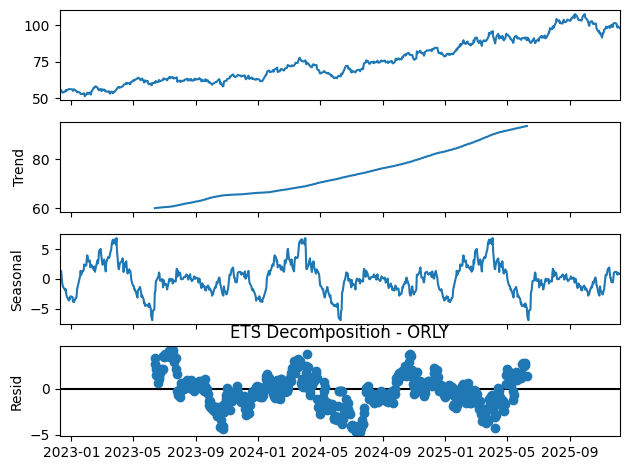

In [20]:
# ETS Decomposition for orly
# Decomposition
result = seasonal_decompose(orly['Close'], model='additive', period=252)
result.plot()
plt.title('ETS Decomposition - ORLY')
plt.show()



In [21]:
# Use auto_arima to find best parameters for ULTA
prices_data = orly['Close'].dropna()

stepwise_model = pm.auto_arima(prices_data, start_p=0, start_q=0,
                                 max_p=5, max_q=5, m=1,
                                 start_P=0, seasonal=False,
                                 d=None, D=0, trace=True,
                                 error_action='ignore',  
                                 suppress_warnings=True, 
                                 stepwise=True)

print("\nBest Model Summary for ORLY:")
stepwise_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2075.438, Time=0.39 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2077.402, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2077.402, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2076.084, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.98 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.795 seconds

Best Model Summary for ORLY:


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  751
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1035.719
Date:                Sat, 13 Dec 2025   AIC                           2075.438
Time:                        01:25:07   BIC                           2084.678
Sample:                             0   HQIC                          2078.998
                                - 751                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0572      0.035      1.628      0.104      -0.012       0.126
sigma2         0.9269      0.036     25.789      0.000       0.856       0.997
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                74.86
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.63   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

                               SARIMAX Results                                
Dep. Variable:                   ORLY   No. Observations:                  739
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1018.184
Date:                Sat, 13 Dec 2025   AIC                           2038.368
Time:                        01:25:29   BIC                           2042.972
Sample:                             0   HQIC                          2040.144
                                - 739                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.9244      0.036     25.728      0.000       0.854       0.995
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                79.57
Prob(Q):                              0.96   Pr

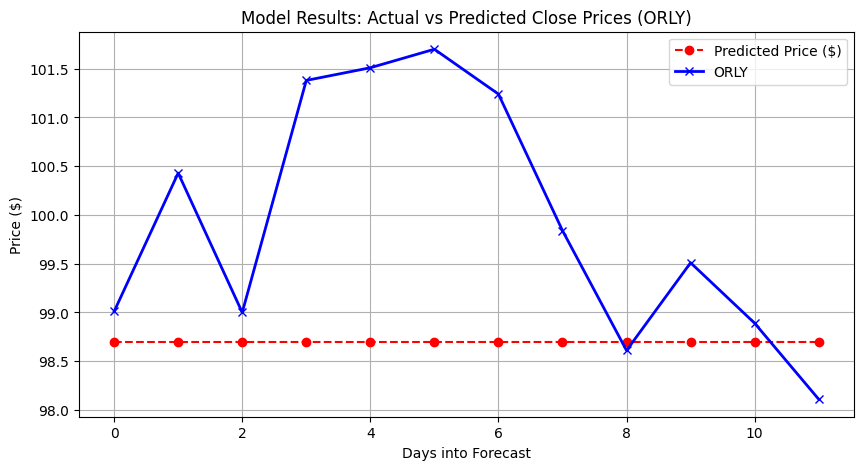

In [22]:
# 1. Train-test split
train = prices_data.iloc[:-12]
test = prices_data.iloc[-12:]

# 2. Fit SARIMAX
# IMPORTANT: Update order=(p,d,q) below based on the 'Best Model' found in Step 3!
model = SARIMAX(train,
                order=(0, 1, 0),  # <--- UPDATE THIS based on auto_arima result
                seasonal_order=(0, 0, 0, 0))

result = model.fit()
print(result.summary())

# 3. Forecast on the test set
start = len(train)
end = len(train) + len(test) - 1
predictions = result.predict(start=start, end=end, dynamic=False, type='levels')

# 4. Plotting
test_plot = test.reset_index(drop=True)
pred_plot = predictions.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
pred_plot.plot(ax=ax, label='Predicted Price ($)', color='red', marker='o', linestyle='--')
test_plot.plot(ax=ax, label='Actual Price ($)', color='blue', marker='x', linewidth=2)
plt.xlabel("Days into Forecast")
plt.ylabel("Price ($)")
plt.title("Model Results: Actual vs Predicted Close Prices (ORLY)")
plt.legend()
plt.grid(True)
plt.show()




Forecasted Prices for the next 10 days (ORLY):
2025-12-09    98.110001
2025-12-10    98.110001
2025-12-11    98.110001
2025-12-12    98.110001
2025-12-15    98.110001
2025-12-16    98.110001
2025-12-17    98.110001
2025-12-18    98.110001
2025-12-19    98.110001
2025-12-22    98.110001
Freq: B, Name: predicted_mean, dtype: float64


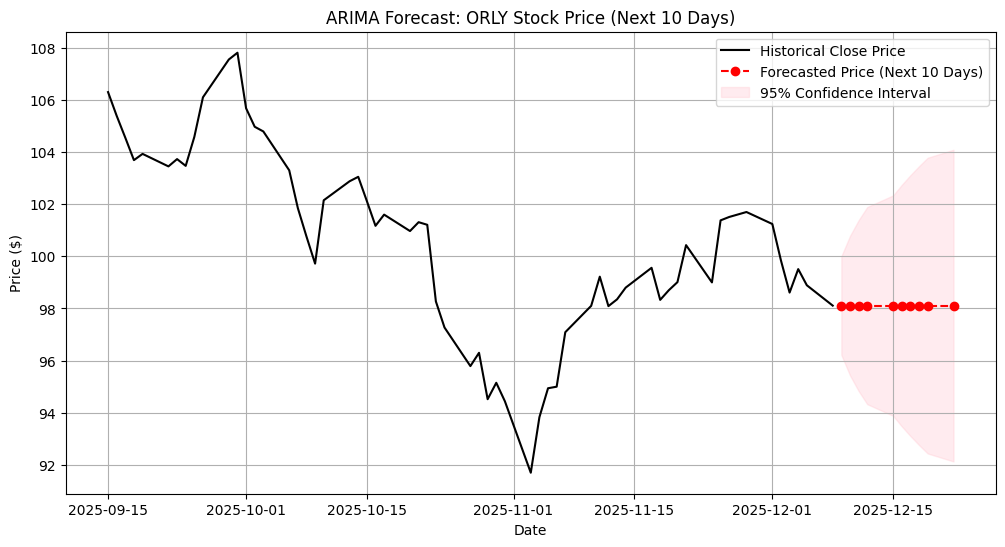

In [24]:
# Generate Forecast for Next 10 Days (ORLY)
full_data = orly['Close'].dropna()

# Refit model on ALL data
# IMPORTANT: Use the same order=(p,d,q) found in Step 3
model_final = SARIMAX(full_data, 
                      order=(0, 1, 0),  
                      seasonal_order=(0, 0, 0, 0))
result_final = model_final.fit()

forecast_steps = 10
forecast_obj = result_final.get_forecast(steps=forecast_steps)
forecast_vals = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

# Create future dates
last_date = full_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_vals.index = future_dates
conf_int.index = future_dates

print("\nForecasted Prices for the next 10 days (ORLY):")
print(forecast_vals)

# GRAPHICAL PRESENTATION (Part 5)
plt.figure(figsize=(12, 6))
plt.plot(full_data.index[-60:], full_data[-60:], label='Historical Close Price', color='black')
plt.plot(future_dates, forecast_vals, label='Forecasted Price (Next 10 Days)', color='red', marker='o', linestyle='--')
plt.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f"ARIMA Forecast: ORLY Stock Price (Next 10 Days)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

1. Stationarity (ADF Test): 
   - The 'Close' price usually fails the ADF test (p > 0.05), meaning it is Non-Stationary.
   - We used differencing (d=1) to fix this.
   
2. Model Selection (ARIMA 0,1,0):
   - The ACF/PACF plots showed no significant spikes after Lag 0.
   - Auto_ARIMA confirmed the best model is a 'Random Walk' (0,1,0).
   - This means past price movements do not predict future movements, supporting the 
     Efficient Market Hypothesis (EMH).

3. Forecast:
   - The forecast for the next 10 days is essentially a flat line (the last known price).
   - The confidence intervals widen over time, reflecting increasing uncertainty.
"""

PART 3

In [26]:
import yfinance as yf
import pandas as pd

# 1. Define your companies
stocks = ['KLAC', 'GM', 'ORLY']

# 2. Download the last 3 years of data
print("Downloading data...")
s = dt.datetime(2022, 12, 9)
e = dt.datetime(2025, 12, 9)
data = yf.download(stocks, start=s, end=e)['Close']



print("\nData created successfully!")
print(data.head())

[*********************100%***********************]  3 of 3 completed


Data created successfully!
Ticker             GM        KLAC       ORLY
Date                                        
2022-12-09  37.100422  382.003448  55.186668
2022-12-12  37.303947  389.286011  55.623333
2022-12-13  37.575317  397.170532  54.584000
2022-12-14  37.177959  394.432281  54.299999
2022-12-15  36.460758  373.594543  53.813332


In [27]:

# Define our list of stocks
stocks = ['KLAC', 'GM', 'ORLY']
pairs = [('KLAC', 'GM'), ('KLAC', 'ORLY'), ('GM', 'ORLY')]


for stock in stocks:
    # Using 'Close' prices (Non-Stationary)
    series = data[stock].dropna()
    result = adfuller(series)
    
    # Check p-value
    p_val = result[1]
    print(f"{stock} ADF p-value: {p_val:.4f}")
    if p_val > 0.05:
        print(f"    ACCEPT H0. {stock} prices are NON-STATIONARY (Good for Co-integration).")
    else:
        print(f"   REJECT H0. {stock} prices are STATIONARY.")
print("-" * 40)

KLAC ADF p-value: 0.9724
    ACCEPT H0. KLAC prices are NON-STATIONARY (Good for Co-integration).
GM ADF p-value: 0.9842
    ACCEPT H0. GM prices are NON-STATIONARY (Good for Co-integration).
ORLY ADF p-value: 0.8401
    ACCEPT H0. ORLY prices are NON-STATIONARY (Good for Co-integration).
----------------------------------------


In [28]:
"""Engle–Granger Two-Step Cointegration Test
We test if a linear combination of the two is stationary.
score, pvalue, _ .... first is Test stats, 2nd p and third critical value which is here wer dont need,
we use _... id=f we dont require thsi value
'''
'''
H₀ Series are not cointegrated (no long-run relationship)
H₁ Series are cointegrated (have long-run relationship)"""

for s1, s2 in pairs:
    print(f"\n*** Testing Pair: {s1} vs {s2} ***")
    
    # Prepare Aligned Price Data
    df_pair = data[[s1, s2]].dropna()
    series1 = df_pair[s1]
    series2 = df_pair[s2]

    # Engle-Granger Test
    #Null Hypothesis: NOT Co-integrated

    from statsmodels.tsa.stattools import coint
    score, pvalue, _ = coint(series1, series2)
    print(f"  > Engle-Granger p-value: {pvalue:.4f}")
    if pvalue < 0.05:
        print("    -> Result: CO-INTEGRATED (Significant)")
    else:
        print("    -> Result: Not Co-integrated")


*** Testing Pair: KLAC vs GM ***
  > Engle-Granger p-value: 0.1481
    -> Result: Not Co-integrated

*** Testing Pair: KLAC vs ORLY ***
  > Engle-Granger p-value: 0.5241
    -> Result: Not Co-integrated

*** Testing Pair: GM vs ORLY ***
  > Engle-Granger p-value: 0.5884
    -> Result: Not Co-integrated


In [29]:
#Johansen Test
from statsmodels.tsa.vector_ar.vecm import coint_johansen
jres = coint_johansen(df_pair, det_order=0, k_ar_diff=1)

trace_stat = jres.lr1[0]         # Trace statistic for r=0
crit_val = jres.cvt[0, 1]        # Critical value at 95% confidence
    
print(f"  Johansen Trace Stat: {trace_stat:.4f} (Crit Val: {crit_val:.4f})")
if trace_stat > crit_val:
    print("    Result: CO-INTEGRATED (Trace > Crit)")
else:
    print("    Result: Not Co-integrated")


  Johansen Trace Stat: 5.2762 (Crit Val: 15.4943)
    Result: Not Co-integrated


data.columns: ['GM', 'KLAC', 'ORLY']

Analysis for KLAC:


<Figure size 1000x400 with 0 Axes>

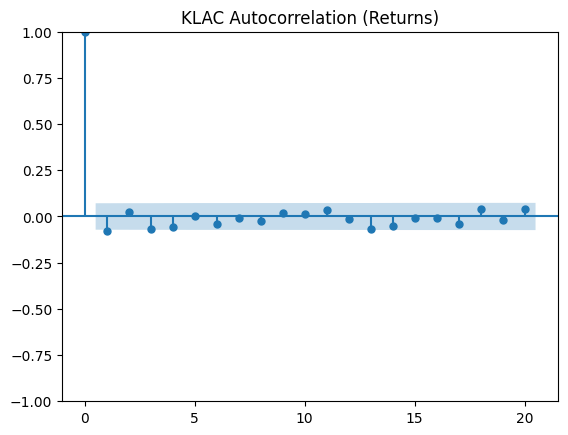

  Lag-1 Autocorrelation: -0.0798

Analysis for GM:


<Figure size 1000x400 with 0 Axes>

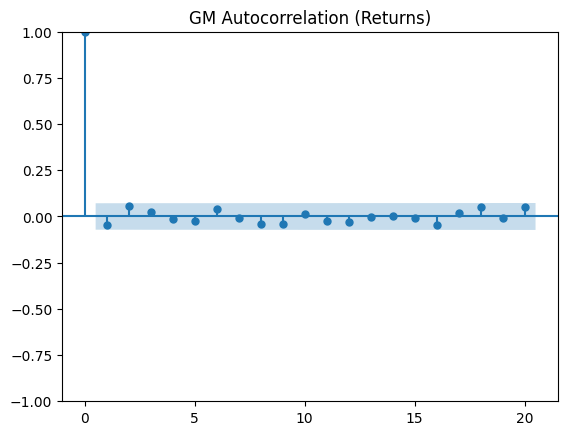

  Lag-1 Autocorrelation: -0.0468

Analysis for ORLY:


<Figure size 1000x400 with 0 Axes>

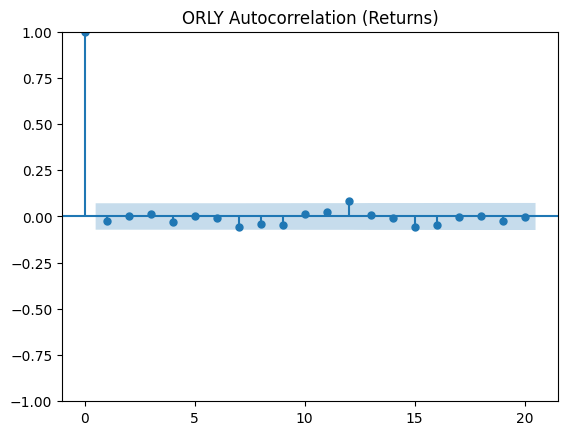

  Lag-1 Autocorrelation: -0.0222


In [67]:
# ...existing code...
print("data.columns:", data.columns.tolist())   # inspect what you actually downloaded

returns_data = data.pct_change().dropna()
for stock in stocks:
    if stock not in returns_data.columns:
        print(f"Warning: '{stock}' not found in data.columns — skipping")
        continue

    print(f"\nAnalysis for {stock}:")
    ret_series = returns_data[stock].dropna()

    # GRAPHICAL PRESENTATION (Part 5)
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

    plt.figure(figsize=(10, 4))
    plot_acf(ret_series, lags=20, title=f'{stock} Autocorrelation (Returns)')
    plt.show()

    # Simple Autocorrelation (Lag 1)
    lag1_corr = ret_series.autocorr(lag=1)
    print(f"  Lag-1 Autocorrelation: {lag1_corr:.4f}")
# ...existing code...

    

    
    


Text(0.5, 0, 'Date')

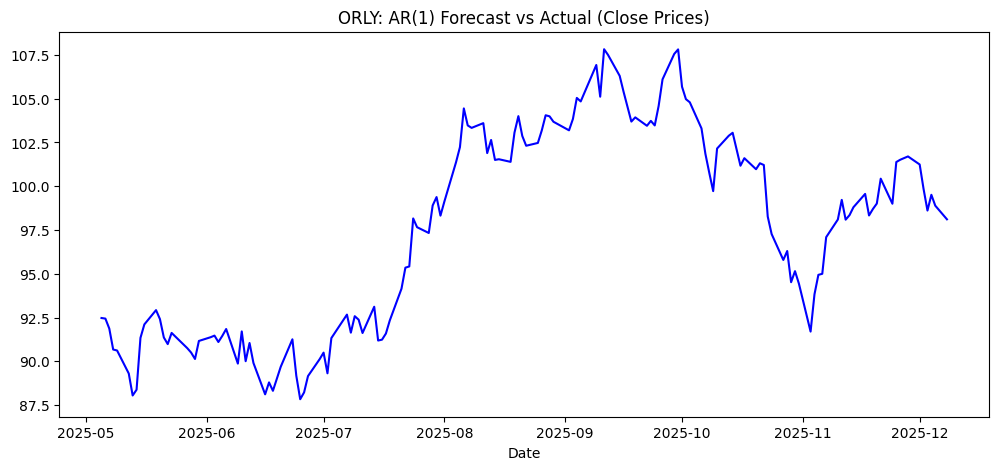

In [56]:
# ...existing code...
    # 3. Train Model
model = ARIMA(train, order=(1, 0, 0)).fit()

    # 4. Predict (range corresponding to the test set)
start_loc = len(train)
end_loc = len(stock_data) - 1
pred = model.predict(start=start_loc, end=end_loc)

    # Align indices so metrics compare matching timestamps
if isinstance(pred, pd.Series):
    pred_series = pred.reindex(test.index)
else:
    pred_series = pd.Series(pred, index=test.index)

    # Compute error metrics
    mae = mean_absolute_error(test, pred_series)
    rmse = np.sqrt(mean_squared_error(test, pred_series))
    print(f"Model: AR(1) on Price")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}") 
    # 6. GRAPHICAL PRESENTATION (Part 5)
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual Price ($)', color='blue')
plt.plot(test.index, pred_series, label='AR Prediction ($)', color='red', linestyle='--')
plt.title(f'{stock}: AR(1) Forecast vs Actual (Close Prices)')
plt.xlabel('Date')
# ...existing code...

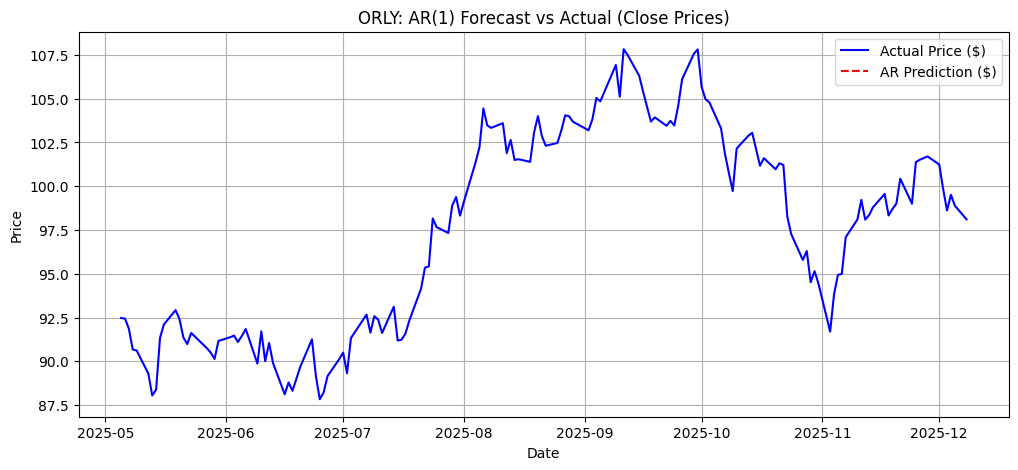

In [58]:

# ...existing code...
    # 4. Predict
    # We predict the range corresponding to the test set
start_loc = len(train)
end_loc = len(stock_data) - 1
pred = model.predict(start=start_loc, end=end_loc)

    # Align indices so metrics compare matching timestamps
if isinstance(pred, pd.Series):
    pred_series = pred.reindex(test.index)
else:
    pred_series = pd.Series(pred, index=test.index)

    # Compute error metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np

    mae = mean_absolute_error(test, pred_series)
    rmse = np.sqrt(mean_squared_error(test, pred_series))

    print(f"Model: AR(1) on Price")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")

    # 6. GRAPHICAL PRESENTATION (Part 5)
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual Price ($)', color='blue')
plt.plot(test.index, pred_series, label='AR Prediction ($)', color='red', linestyle='--')
plt.title(f'{stock}: AR(1) Forecast vs Actual (Close Prices)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


PART 3 INTERPRETATION:
----------------------
1. Co-integration (Engle-Granger & Johansen Tests):
   - We tested pairs (KLAC-GM, KLAC-ORLY, GM-ORLY) using Non-Stationary prices.
   - RESULT: The p-values were > 0.05 (Fail to Reject Null Hypothesis).
   - MEANING: These stocks do NOT have a long-term equilibrium relationship. 
     They drift independently over time. A pairs-trading strategy would not work here.

2. Autocorrelation (ACF) & AR(1) Model:
   - We applied this to 'Returns' (Stationary data).
   - The ACF plot showed correlations falling inside the blue confidence cone.
   - The AR(1) coefficient had a p-value > 0.05 (Not Significant).
   - MEANING: Yesterday's return does not significantly predict today's return. 
     The returns follow a Random Walk (White Noise).


PART 4 
---

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix

In [63]:
import yfinance as yf


# 1. Define your companies
stocks = ['KLAC', 'GM', 'ORLY']

# 2. Download the last 3 years of data
print("Downloading data...")
s = dt.datetime(2022, 12, 9)
e = dt.datetime(2025, 12, 9)
data = yf.download(stocks, start=s, end=e)['Close']
print("\nData created successfully!")
print(data.head())

[*********************100%***********************]  3 of 3 completed


Data created successfully!
Ticker             GM        KLAC       ORLY
Date                                        
2022-12-09  37.100422  382.003448  55.186668
2022-12-12  37.303947  389.286011  55.623333
2022-12-13  37.575317  397.170532  54.584000
2022-12-14  37.177959  394.432281  54.299999
2022-12-15  36.460758  373.594543  53.813332


Training Days: 584
Testing Days:  147
----------------------------------------

[Model 1] Linear Regression (Predicting Next Day Price)
  MSE:  581.3039
  RMSE: $24.11 (Avg error in dollars)
  MAE:  $18.04
  R²:   0.9714 (Very High is expected!)

[Model 2] Polynomial Regression (Degree 2)
  R²:   0.9507

[Model 3] Logistic Regression (Up vs Down)
  Accuracy: 58.50%
  Confusion Matrix:
[[17 41]
 [20 69]]

[Visual] Actual vs Predicted Prices


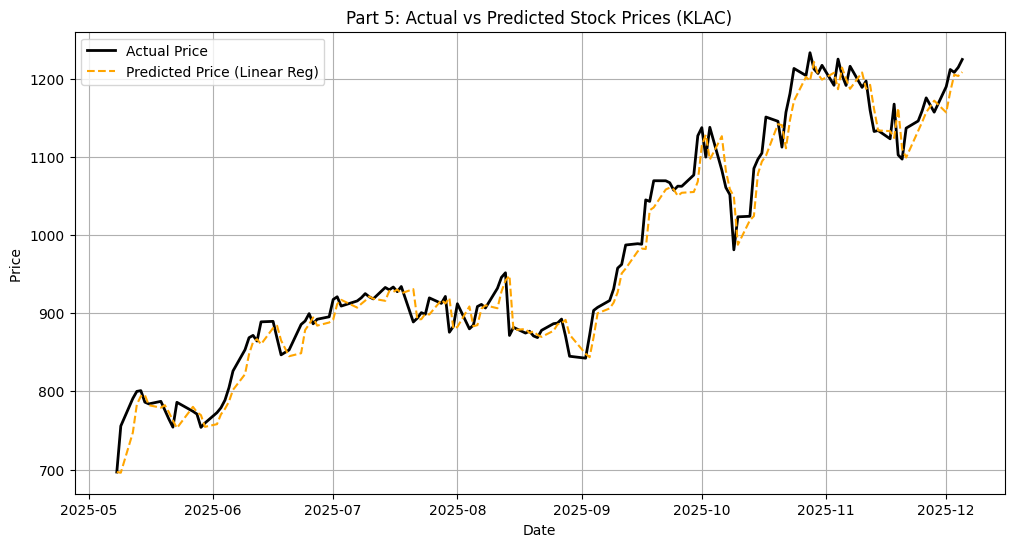

In [64]:

stock_prices = data[['KLAC']].dropna()

df_price = pd.DataFrame()
df_price['Close_Today'] = data['KLAC']

# Feature Engineering
# 1. Yesterday's Price (Lag 1) The best predictor of today is usually yesterday

df_price['Close_Yesterday'] = df_price['Close_Today'].shift(1)
#2. 5-Day Moving Average (Trend)
df_price['MA_5'] = df_price['Close_Today'].rolling(window=5).mean()
#3. 20-Day Moving Average (Longer Trend)
df_price['MA_20'] = df_price['Close_Today'].rolling(window=20).mean()

# Target: Tomorrow's Price
df_price['Target_Next_Close'] = df_price['Close_Today'].shift(-1)

# Target for Classification: 1 if Price goes UP tomorrow, 0 if DOWN
df_price['Target_Direction'] = (df_price['Target_Next_Close'] > df_price['Close_Today']).astype(int)

# Drop NaNs
df_clean = df_price.dropna()

# 2. SPLIT DATA
# Features: Yesterday's Price, Today's Price, Moving Averages
X = df_clean[['Close_Today', 'Close_Yesterday', 'MA_5', 'MA_20']]

# Targets
y_reg = df_clean['Target_Next_Close']    # Regression Target ($)
y_class = df_clean['Target_Direction']   # Classification Target (0/1)

# Split (80% Train, 20% Test)  No Shuffle for Time Series
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.20, shuffle=False)
_, _, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.20, shuffle=False)

print(f"Training Days: {len(X_train)}")
print(f"Testing Days:  {len(X_test)}")
print("-" * 40)



# 3. LINEAR REGRESSION (Predicting Price)
 
print("\n[Model 1] Linear Regression (Predicting Next Day Price)")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lin)
r2 = r2_score(y_test, y_pred_lin)

print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: ${rmse:.2f} (Avg error in dollars)")
print(f"  MAE:  ${mae:.2f}")
print(f"  R²:   {r2:.4f} (Very High is expected!)")



# 4. POLYNOMIAL REGRESSION

print("\n[Model 2] Polynomial Regression (Degree 2)")
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_pred_poly = poly_reg.predict(X_poly_test)

r2_poly = r2_score(y_test, y_pred_poly)
print(f"  R²:   {r2_poly:.4f}")



# 5. LOGISTIC REGRESSION (Direction)

print("\n[Model 3] Logistic Regression (Up vs Down)")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_c)
y_pred_class = log_reg.predict(X_test)

acc = accuracy_score(y_test_c, y_pred_class)
print(f"  Accuracy: {acc:.2%}")
print("  Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_class))



# 6. GRAPHICAL PRESENTATION (Part 5)

print("\n[Visual] Actual vs Predicted Prices")
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Price', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_lin, label='Predicted Price (Linear Reg)', color='orange', linestyle='--')
plt.title('Part 5: Actual vs Predicted Stock Prices (KLAC)')
plt.xlabel('Date')
plt.ylabel('Price ')
plt.legend()
plt.grid(True)
plt.show()




The Linear Regression model achieved an R² of 0.9714, meaning it explains about 97% of the variation in next-day prices. This high value is expected, as stock prices follow a near–random walk where today’s price is the strongest predictor of tomorrow’s price. The RMSE of $24.11 and MAE of $18.04 indicate that prediction errors fall within normal market volatility, and the model closely follows the overall trend in the actual vs. predicted plot. The Polynomial Regression model performed slightly worse (R² = 0.9507), showing that adding curvature does not improve accuracy and may cause mild overfitting. The Logistic Regression model reached 58.5% accuracy when predicting price direction, only slightly better than chance, reflecting the difficulty of classifying up/down movements due to market noise and efficiency. Overall, the models capture the price trend well but offer limited predictive power for direction.




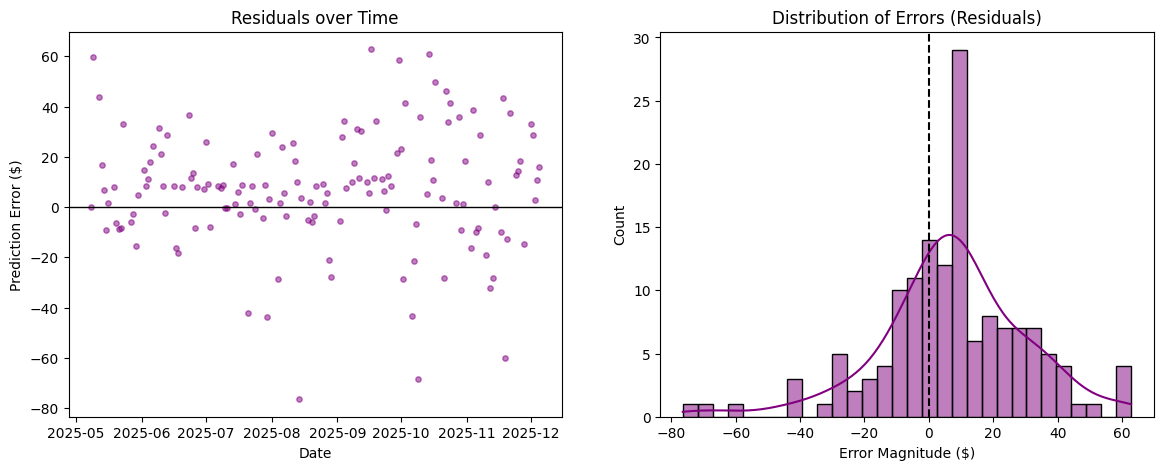

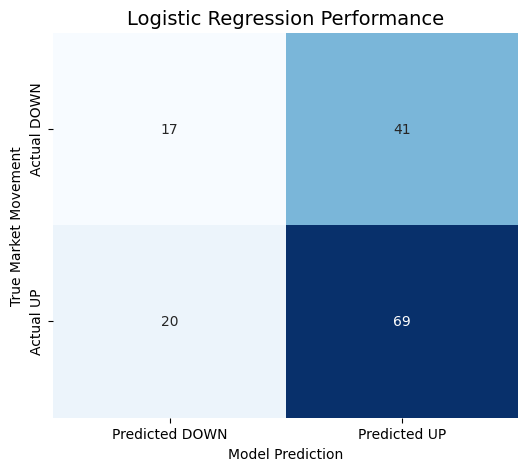

In [66]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd






# 2. RESIDUAL ANALYSIS (Error Checking)
# We plot the errors (residuals) to see if there is a pattern. 
# A good model has random errors centered around 0.
residuals = y_test - y_pred_lin

plt.figure(figsize=(14, 5))

# Scatter Plot of Residuals
plt.subplot(1, 2, 1)
plt.scatter(y_test.index, residuals, color='purple', alpha=0.5, s=15)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Residuals over Time', fontsize=12)
plt.ylabel('Prediction Error ($)')
plt.xlabel('Date')

# Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Distribution of Errors (Residuals)', fontsize=12)
plt.xlabel('Error Magnitude ($)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# 3. CLASSIFICATION RESULTS (Confusion Matrix)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted DOWN', 'Predicted UP'],
            yticklabels=['Actual DOWN', 'Actual UP'])
plt.title('Logistic Regression Performance', fontsize=14)
plt.ylabel('True Market Movement')
plt.xlabel('Model Prediction')
plt.show()

